In [30]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow_decision_forests as tfdf
import pandas as pd

https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [31]:
predictors = ["grid", "position", "pos_delta", "driver_code", "constructor_code", "circuit_code", "grid_rolling",
              "position_rolling", "pos_delta_rolling"]

In [32]:
data = pd.read_csv("./data/final_rolling.csv")

In [33]:
data.dropna(subset="position", inplace=True)

In [34]:
data["position"] = data["position"].astype("int")

In [35]:
training = data[data["year"] < 2022]
test = data[data["year"] >= 2022]

In [36]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(training[predictors], label="position")
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(test[predictors])

In [37]:
model = tfdf.keras.RandomForestModel()

Use /var/folders/hk/ffpx1y0s2cn133v15g3yks080000gn/T/tmpe8tz8lbu as temporary training directory


In [38]:
model.fit(train_ds)

Reading training dataset...
Training dataset read in 0:00:00.091456. Found 4153 examples.
Training model...


[INFO 24-09-10 13:41:03.4562 CEST kernel.cc:1233] Loading model from path /var/folders/hk/ffpx1y0s2cn133v15g3yks080000gn/T/tmpe8tz8lbu/model/ with prefix 48203b135a6740ac


Model trained in 0:00:01.060727
Compiling model...


[INFO 24-09-10 13:41:03.8758 CEST decision_forest.cc:734] Model loaded with 300 root(s), 317270 node(s), and 8 input feature(s).
[INFO 24-09-10 13:41:03.8759 CEST abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 24-09-10 13:41:03.8759 CEST kernel.cc:1061] Use fast generic engine


Model compiled.


In [39]:
predictions = model.predict(test_ds)

2/2 [==============================] - 0s 2ms/step


### Prediction tables:
    Rows - prediction number
    Column - driverId

In [40]:
predictions_df = pd.DataFrame(predictions)

In [41]:
full_table = pd.merge(test, predictions_df, on=test.index)

full_table

,key_0,raceId,grid,position,year,date,time,circuitRef,driverRef,constructorRef,...,11,12,13,14,15,16,17,18,19,20
0,4153,1074,1.0,1,2022,2022-03-20,15:00:00,Bahrain,Leclerc,Ferrari,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4154,1074,3.0,2,2022,2022-03-20,15:00:00,Bahrain,Sainz,Ferrari,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4155,1074,5.0,3,2022,2022-03-20,15:00:00,Bahrain,Hamilton,Mercedes,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4156,1074,9.0,4,2022,2022-03-20,15:00:00,Bahrain,Russell,Mercedes,...,0.010000,0.023333,0.003333,0.000000,0.006667,0.003333,0.000000,0.000000,0.000000,0.000000
4,4157,1074,7.0,5,2022,2022-03-20,15:00:00,Bahrain,Kevin Magnussen,Haas,...,0.026667,0.023333,0.023333,0.040000,0.016667,0.006667,0.016667,0.006667,0.003333,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,5166,1134,20.0,16,2024,2024-07-28,15:00,Spa,Tsunoda,Rb,...,0.006667,0.053333,0.020000,0.163333,0.373333,0.273333,0.056667,0.033333,0.003333,0.006667
1014,5167,1134,18.0,17,2024,2024-07-28,15:00,Spa,Sargeant,Williams,...,0.000000,0.010000,0.006667,0.033333,0.023333,0.250000,0.480000,0.156667,0.036667,0.003333
1015,5168,1134,16.0,18,2024,2024-07-28,15:00,Spa,Hulkenberg,Haas,...,0.006667,0.030000,0.036667,0.093333,0.086667,0.110000,0.196667,0.326666,0.033333,0.040000
1016,5169,1134,19.0,19,2024,2024-07-28,15:00,Spa,Zhou,Sauber,...,0.000000,0.003333,0.010000,0.013333,0.006667,0.036667,0.103333,0.393333,0.340000,0.093333


In [42]:
evaluation = model.make_inspector().evaluation()

In [43]:
evaluation

Evaluation(num_examples=4153, accuracy=0.7972549963881531, loss=0.9200882553956038, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

In [44]:
evaluation.accuracy

0.7972549963881531

In [45]:
preds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [46]:
full_table["max_pred"] = full_table[preds].max(axis=1)

In [47]:
full_table[["raceId", "driverRef", "constructorRef", "circuitRef", "grid", 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]]

,raceId,driverRef,constructorRef,circuitRef,grid,1,2,3,4,5,6,7,8,9,10
0,1074,Leclerc,Ferrari,Bahrain,1.0,0.769999,0.070000,0.086667,0.043333,0.020000,0.003333,0.003333,0.000000,0.000000,0.003333
1,1074,Sainz,Ferrari,Bahrain,3.0,0.143333,0.643333,0.176667,0.016667,0.006667,0.000000,0.013333,0.000000,0.000000,0.000000
2,1074,Hamilton,Mercedes,Bahrain,5.0,0.063333,0.273333,0.503333,0.113333,0.036667,0.006667,0.000000,0.003333,0.000000,0.000000
3,1074,Russell,Mercedes,Bahrain,9.0,0.003333,0.040000,0.093333,0.306666,0.156667,0.090000,0.086667,0.066667,0.073333,0.036667
4,1074,Kevin Magnussen,Haas,Bahrain,7.0,0.010000,0.010000,0.050000,0.063333,0.190000,0.233333,0.066667,0.090000,0.096667,0.026667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,1134,Tsunoda,Rb,Spa,20.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003333,0.000000,0.006667
1014,1134,Sargeant,Williams,Spa,18.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1015,1134,Hulkenberg,Haas,Spa,16.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.006667,0.000000,0.003333,0.010000,0.020000
1016,1134,Zhou,Sauber,Spa,19.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [48]:
inspector = model.make_inspector()

In [49]:
full_table

,key_0,raceId,grid,position,year,date,time,circuitRef,driverRef,constructorRef,...,12,13,14,15,16,17,18,19,20,max_pred
0,4153,1074,1.0,1,2022,2022-03-20,15:00:00,Bahrain,Leclerc,Ferrari,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.769999
1,4154,1074,3.0,2,2022,2022-03-20,15:00:00,Bahrain,Sainz,Ferrari,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.643333
2,4155,1074,5.0,3,2022,2022-03-20,15:00:00,Bahrain,Hamilton,Mercedes,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.503333
3,4156,1074,9.0,4,2022,2022-03-20,15:00:00,Bahrain,Russell,Mercedes,...,0.023333,0.003333,0.000000,0.006667,0.003333,0.000000,0.000000,0.000000,0.000000,0.306666
4,4157,1074,7.0,5,2022,2022-03-20,15:00:00,Bahrain,Kevin Magnussen,Haas,...,0.023333,0.023333,0.040000,0.016667,0.006667,0.016667,0.006667,0.003333,0.000000,0.233333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1013,5166,1134,20.0,16,2024,2024-07-28,15:00,Spa,Tsunoda,Rb,...,0.053333,0.020000,0.163333,0.373333,0.273333,0.056667,0.033333,0.003333,0.006667,0.373333
1014,5167,1134,18.0,17,2024,2024-07-28,15:00,Spa,Sargeant,Williams,...,0.010000,0.006667,0.033333,0.023333,0.250000,0.480000,0.156667,0.036667,0.003333,0.480000
1015,5168,1134,16.0,18,2024,2024-07-28,15:00,Spa,Hulkenberg,Haas,...,0.030000,0.036667,0.093333,0.086667,0.110000,0.196667,0.326666,0.033333,0.040000,0.326666
1016,5169,1134,19.0,19,2024,2024-07-28,15:00,Spa,Zhou,Sauber,...,0.003333,0.010000,0.013333,0.006667,0.036667,0.103333,0.393333,0.340000,0.093333,0.393333


In [50]:
tree = inspector.extract_tree(tree_idx=0)

In [51]:
import dtreeviz as dt

In [52]:
features = [f.name for f in model.make_inspector().features()]

In [53]:
features

['circuit_code',
 'constructor_code',
 'driver_code',
 'grid',
 'grid_rolling',
 'pos_delta',
 'pos_delta_rolling',
 'position_rolling']

In [54]:
training.dropna(inplace=True)

/var/folders/hk/ffpx1y0s2cn133v15g3yks080000gn/T/ipykernel_7950/736322629.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [55]:
training

,raceId,grid,position,year,date,time,circuitRef,driverRef,constructorRef,circuit_code,driver_code,constructor_code,pos_delta,grid_rolling,position_rolling,pos_delta_rolling
48,340,5.0,1,2010,2010-04-18,06:00:00,Shanghai,Button,Mclaren,24,11,13,4.0,9.666667,5.333333,4.333333
49,340,6.0,2,2010,2010-04-18,06:00:00,Shanghai,Hamilton,Mclaren,24,23,13,4.0,11.666667,5.000000,6.666667
50,340,4.0,3,2010,2010-04-18,06:00:00,Shanghai,Rosberg,Mercedes,24,60,14,1.0,4.333333,4.333333,0.000000
51,340,3.0,4,2010,2010-04-18,06:00:00,Shanghai,Alonso,Ferrari,24,3,5,-1.0,8.333333,6.000000,2.333333
52,340,8.0,5,2010,2010-04-18,06:00:00,Shanghai,Kubica,Renault,24,34,18,3.0,8.000000,5.666667,2.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4148,1073,15.0,11,2021,2021-12-12,13:00:00,Yas Marina,Vettel,Aston Martin,32,73,3,4.0,12.000000,9.333333,2.666667
4149,1073,10.0,12,2021,2021-12-12,13:00:00,Yas Marina,Ricciardo,Mclaren,32,58,13,-2.0,8.000000,7.333333,0.666667
4150,1073,13.0,13,2021,2021-12-12,13:00:00,Yas Marina,Stroll,Aston Martin,32,67,3,0.0,17.000000,12.333333,4.666667
4151,1073,19.0,14,2021,2021-12-12,13:00:00,Yas Marina,Mick Schumacher,Haas,32,47,7,5.0,16.000000,17.666667,-1.666667


In [56]:
viz_model = dt.model(
    model=model,
    X_train=training[features],
    y_train=training["position"]-1,
    feature_names=features,
    target_name="position",
    tree_index=0
)

In [57]:
viz_model.view(depth_range_to_display=[0,3], scale=0.75, orientation="LR").save("./tree.svg")

In [58]:
import tensorflow as tf

In [59]:
one_prediction = tf.argmax(predictions, axis=-1)

In [60]:
one_prediction

<tf.Tensor: shape=(1018,), dtype=int64, numpy=array([ 1,  2,  3, ..., 18, 18, 15])>

In [61]:
confusion = tf.math.confusion_matrix(labels=test["position"], predictions=one_prediction)

In [62]:
cm_df = pd.DataFrame(confusion)

In [63]:
import seaborn as sns

<Axes: >

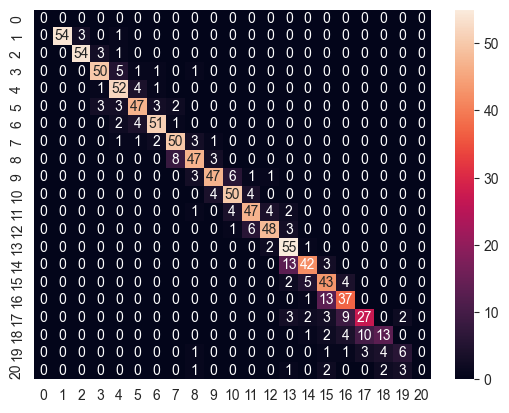

In [64]:
sns.heatmap(cm_df, annot=True)

In [65]:
cm_df.style.background_gradient(cmap="coolwarm")

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,54,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,54,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,50,5,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,52,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,3,3,47,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,2,4,51,1,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,1,1,2,50,3,1,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,8,47,3,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,3,47,6,1,1,0,0,0,0,0,0,0,0
